# CNN Practice Example

## Problem Statement

Build a Convolutional Neural Network (CNN) using TensorFlow and Keras to classify handwritten digits from the MNIST dataset.

## About the Dataset

Dataset Name: MNIST

Image Size: 28 × 28 pixels (Grayscale)

Training Images: 60,000

Testing Images: 10,000

Classes: 10 (Digits 0–9)

## Objective

Train a CNN model to recognize handwritten digits and evaluate its performance on unseen test images.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


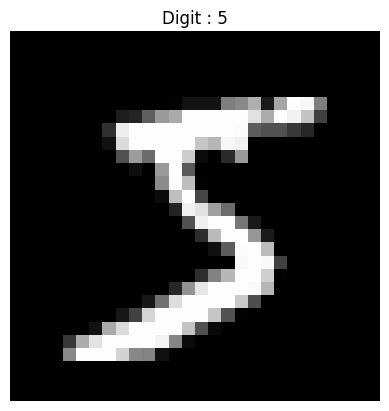

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Started...

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 31ms/step - accuracy: 0.9603 - loss: 0.1299 - val_accuracy: 0.9845 - val_loss: 0.0493
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accuracy: 0.9859 - loss: 0.0440 - val_accuracy: 0.9870 - val_loss: 0.0384
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 32ms/step - accuracy: 0.9902 - loss: 0.0300 - val_accuracy: 0.9907 - val_loss: 0.0267
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9935 - loss: 0.0205 - val_accuracy: 0.9905 - val_loss: 0.0275
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9949 - loss: 0.0150 - val_accuracy: 0.9900 - val_loss: 0.0316

Training Completed!

Model Evaluation
-----------------------
Loss : 0.0316
Accuracy : 99.0 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

Predicted Labels
[7 2 1 0 4]

Actual Labels
[7 2 1 0 4]


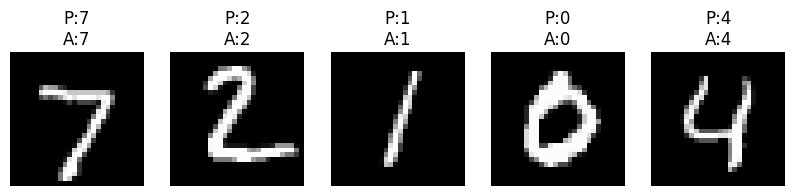


Model Summary
-----------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

New Image Prediction
-----------------------
Predicted Digit : 5
Actual Digit : 5


In [2]:
# ==========================================
# CNN Practice Example
# Image Classification using MNIST Dataset
# ==========================================

# Step 1: Import Libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------
# Step 2: Load Dataset
# ------------------------------------------

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# ------------------------------------------
# Step 3: Normalize Images
# ------------------------------------------

X_train = X_train / 255.0
X_test = X_test / 255.0

# ------------------------------------------
# Step 4: Reshape Images
# ------------------------------------------

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# ------------------------------------------
# Step 5: Display One Image
# ------------------------------------------

plt.imshow(X_train[0], cmap="gray")
plt.title(f"Digit : {y_train[0]}")
plt.axis("off")
plt.show()

# ------------------------------------------
# Step 6: Build CNN Model
# ------------------------------------------

model = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        input_shape=(28,28,1)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(
        units=128,
        activation="relu"
    ),

    Dense(
        units=10,
        activation="softmax"
    )

])

# ------------------------------------------
# Step 7: Compile Model
# ------------------------------------------

model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

# ------------------------------------------
# Step 8: Train Model
# ------------------------------------------

print("Training Started...\n")

history = model.fit(

    X_train,

    y_train,

    epochs=5,

    validation_data=(X_test,y_test),

    verbose=1

)

print("\nTraining Completed!")

# ------------------------------------------
# Step 9: Evaluate Model
# ------------------------------------------

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\nModel Evaluation")
print("-----------------------")
print("Loss :", round(loss,4))
print("Accuracy :", round(accuracy*100,2), "%")

# ------------------------------------------
# Step 10: Predict Test Images
# ------------------------------------------

predictions = model.predict(X_test[:5])

print("\nPredicted Labels")

predicted_labels = np.argmax(predictions, axis=1)

print(predicted_labels)

print("\nActual Labels")

print(y_test[:5])

# ------------------------------------------
# Step 11: Display Prediction Images
# ------------------------------------------

plt.figure(figsize=(10,2))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(X_test[i].reshape(28,28), cmap="gray")

    plt.title(f"P:{predicted_labels[i]}\nA:{y_test[i]}")

    plt.axis("off")

plt.show()

# ------------------------------------------
# Step 12: Model Summary
# ------------------------------------------

print("\nModel Summary")
print("-----------------------")

model.summary()

# ------------------------------------------
# Step 13: Predict One New Image
# ------------------------------------------

sample = X_test[15].reshape(1,28,28,1)

prediction = model.predict(sample)

digit = np.argmax(prediction)

print("\nNew Image Prediction")
print("-----------------------")
print("Predicted Digit :", digit)
print("Actual Digit :", y_test[15])